In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.536390
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.285822
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.260000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,0.710000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,0.810000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,0.900000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<Axes: xlabel='target', ylabel='count'>

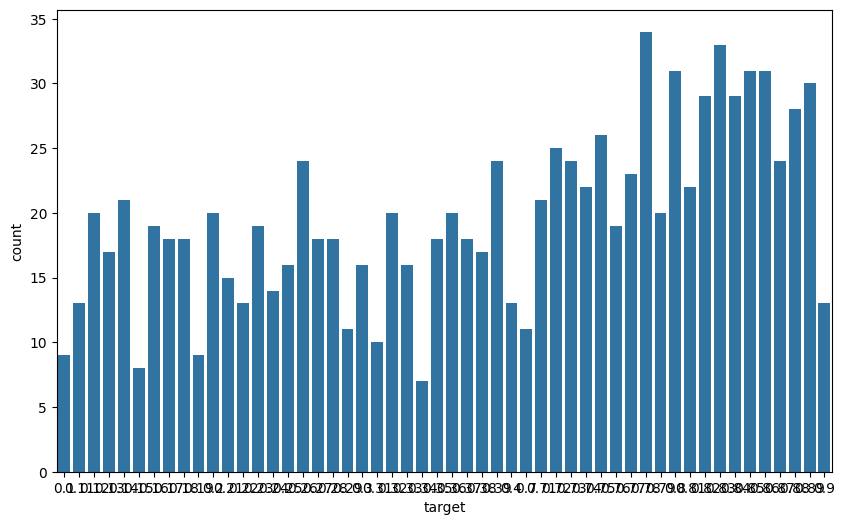

In [9]:
plt.figure(figsize=(10,6))  # adjust the figure size 
sns.countplot(x='target',data=df)

In [10]:
# diving the data into features and target

X=df.drop('target',axis=1)
y=df['target']

X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((768, 13), (257, 13), (768,), (257,))

In [19]:


from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_trained_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

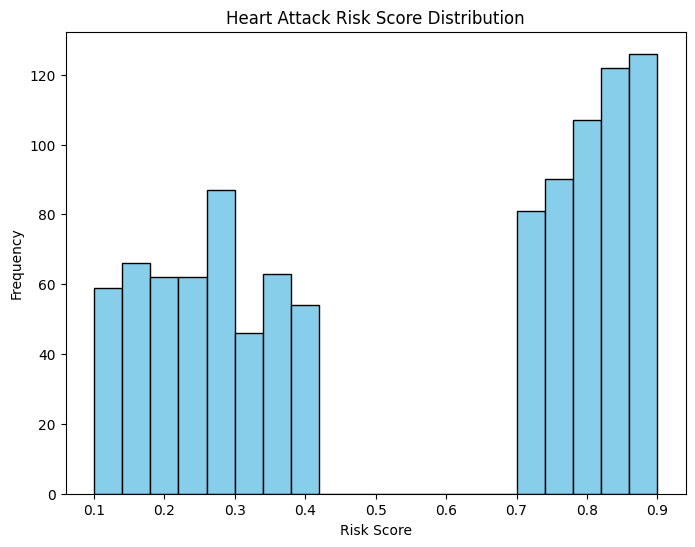

In [16]:
plt.figure(figsize=(8,6))
plt.hist(df['target'], bins=20, color='skyblue', edgecolor='black')
plt.title('Heart Attack Risk Score Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.show()


In [24]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_trained_scaled,y_train)

y_pred=model.predict(X_test_scaled)
y_pred

array([0.78145531, 0.94321341, 0.2651962 , 0.78622615, 0.33335143,
       0.59481926, 0.22169573, 0.18241791, 0.66290157, 0.2720382 ,
       0.80561595, 0.14769123, 0.67852581, 0.67369294, 0.38006515,
       0.71972641, 0.22776081, 0.78204498, 0.64388846, 0.25288047,
       0.6453151 , 0.35228361, 0.55011783, 0.15807304, 0.6453151 ,
       0.57311931, 0.81507656, 0.54200829, 0.18497856, 0.70397525,
       0.61883741, 0.66849511, 0.5321587 , 0.94321341, 0.66167299,
       0.61051222, 0.6453151 , 0.51632627, 0.65600568, 0.72984464,
       0.18241791, 0.34567355, 0.54902948, 0.55011783, 0.4336201 ,
       0.12201994, 0.38989414, 0.52041156, 0.58120313, 0.55107988,
       0.5931976 , 0.14715904, 0.60331616, 0.27362344, 0.81507656,
       0.65600568, 0.49082836, 0.19716485, 0.68834121, 0.74545471,
       0.58080177, 0.31864679, 0.18497856, 0.55107988, 0.1626398 ,
       0.47528969, 0.96257946, 0.58388011, 0.12201994, 0.86412068,
       0.58507941, 0.18497856, 0.50347509, 0.70621142, 0.60524

In [25]:
from sklearn.metrics import mean_absolute_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.35658631097367244
0.18129418791739796


In [26]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_trained_scaled,y_train)
y_pred_ridge=ridgecv.predict(X_test_scaled)

print(r2_score(y_test,y_pred_ridge))

0.3577808898095389


In [27]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [28]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [31]:
import pickle
pickle.dump(ridge,open('model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))